In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from urllib.request import urlopen,Request
from bs4 import BeautifulSoup as bs

In [3]:
df=pd.read_csv('/content/2019.csv')

In [4]:
df.head()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


In [5]:
df.tail()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
151,152,Rwanda,3.334,0.359,0.711,0.614,0.555,0.217,0.411
152,153,Tanzania,3.231,0.476,0.885,0.499,0.417,0.276,0.147
153,154,Afghanistan,3.203,0.350,0.517,0.361,0.000,0.158,0.025
154,155,Central African Republic,3.083,0.026,0.000,0.105,0.225,0.235,0.035
155,156,South Sudan,2.853,0.306,0.575,0.295,0.010,0.202,0.091


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    object 
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 11.1+ KB


In [7]:
df.describe()

,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000
mean,78.500000,5.407096,0.905147,1.208814,0.725244,0.392571,0.184846,0.110603
std,45.177428,1.113120,0.398389,0.299191,0.242124,0.143289,0.095254,0.094538
min,1.000000,2.853000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.750000,4.544500,0.602750,1.055750,0.547750,0.308000,0.108750,0.047000
50%,78.500000,5.379500,0.960000,1.271500,0.789000,0.417000,0.177500,0.085500
75%,117.250000,6.184500,1.232500,1.452500,0.881750,0.507250,0.248250,0.141250
max,156.000000,7.769000,1.684000,1.624000,1.141000,0.631000,0.566000,0.453000


In [8]:
df.columns

Index(['Overall rank', 'Country or region', 'Score', 'GDP per capita',
       'Social support', 'Healthy life expectancy',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption'],
      dtype='object')

In [9]:
df['Country or region'] = df['Country or region'].astype(str)
print(df['Country or region'].dtype)

object


In [10]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Country_encoded'] = le.fit_transform(df['Country or region'])

In [11]:
df['Happiness_per_GDP'] = df['Score'] / df['GDP per capita']
df['Support_Freedom_Index'] = df['Social support'] * df['Freedom to make life choices']
df['Anti_Corruption'] = 1 - df['Perceptions of corruption']

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    object 
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     156 non-null    float64
 9   Country_encoded               156 non-null    int64  
 10  Happiness_per_GDP             156 non-null    float64
 11  Support_Freedom_Index         156 non-null    float64
 12  Anti_Corruption               156 non-null    float64
dtypes: fl

In [13]:
df.isnull().sum()

,0
Overall rank,0
Country or region,0
Score,0
GDP per capita,0
Social support,0
Healthy life expectancy,0
Freedom to make life choices,0
Generosity,0
Perceptions of corruption,0
Country_encoded,0


In [14]:
df.drop_duplicates()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Country_encoded,Happiness_per_GDP,Support_Freedom_Index,Anti_Corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393,43,5.797761,0.945852,0.607
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410,36,5.495300,0.931216,0.590
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341,105,5.076613,0.953946,0.659
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118,57,5.430435,0.959784,0.882
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298,98,5.363897,0.847754,0.702
...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,152,Rwanda,3.334,0.359,0.711,0.614,0.555,0.217,0.411,117,9.286908,0.394605,0.589
152,153,Tanzania,3.231,0.476,0.885,0.499,0.417,0.276,0.147,137,6.787815,0.369045,0.853
153,154,Afghanistan,3.203,0.350,0.517,0.361,0.000,0.158,0.025,0,9.151429,0.000000,0.975
154,155,Central African Republic,3.083,0.026,0.000,0.105,0.225,0.235,0.035,24,118.576923,0.000000,0.965


In [15]:
df.dtypes


,0
Overall rank,int64
Country or region,object
Score,float64
GDP per capita,float64
Social support,float64
Healthy life expectancy,float64
Freedom to make life choices,float64
Generosity,float64
Perceptions of corruption,float64
Country_encoded,int64


In [16]:
df.shape

(156, 13)

In [17]:
#Sort countries by happiness score
df_sorted = df.sort_values(by="Score", ascending=False)
df_sorted

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Country_encoded,Happiness_per_GDP,Support_Freedom_Index,Anti_Corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393,43,5.797761,0.945852,0.607
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410,36,5.495300,0.931216,0.590
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341,105,5.076613,0.953946,0.659
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118,57,5.430435,0.959784,0.882
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298,98,5.363897,0.847754,0.702
...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,152,Rwanda,3.334,0.359,0.711,0.614,0.555,0.217,0.411,117,9.286908,0.394605,0.589
152,153,Tanzania,3.231,0.476,0.885,0.499,0.417,0.276,0.147,137,6.787815,0.369045,0.853
153,154,Afghanistan,3.203,0.350,0.517,0.361,0.000,0.158,0.025,0,9.151429,0.000000,0.975
154,155,Central African Republic,3.083,0.026,0.000,0.105,0.225,0.235,0.035,24,118.576923,0.000000,0.965


In [18]:
Q1 = df['Score'].quantile(0.25)
Q3 = df['Score'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Score'] < lower_bound) | (df['Score'] > upper_bound)]
print("Number of outliers:", len(outliers))
print(outliers[['Country or region','Score']])


Number of outliers: 0
Empty DataFrame
Columns: [Country or region, Score]
Index: []


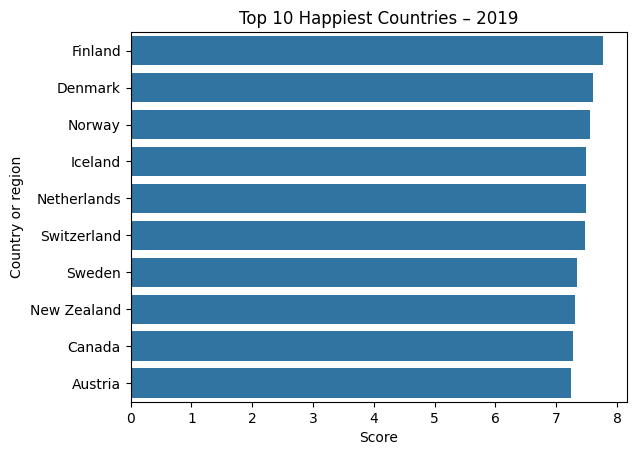

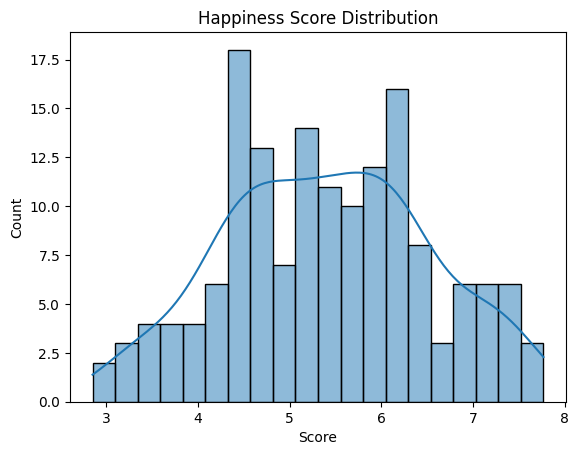

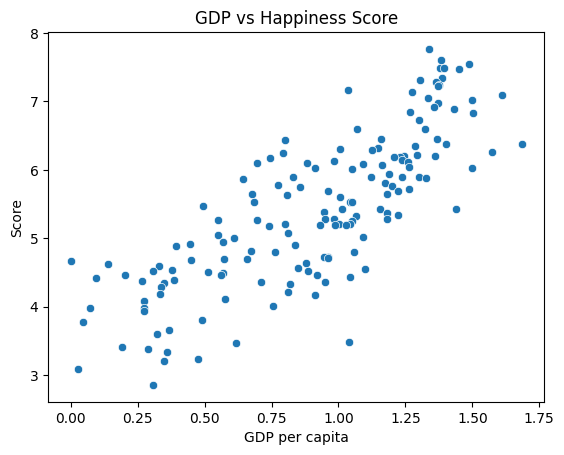

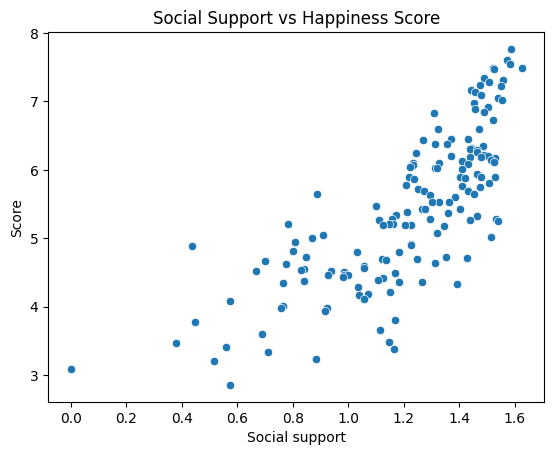

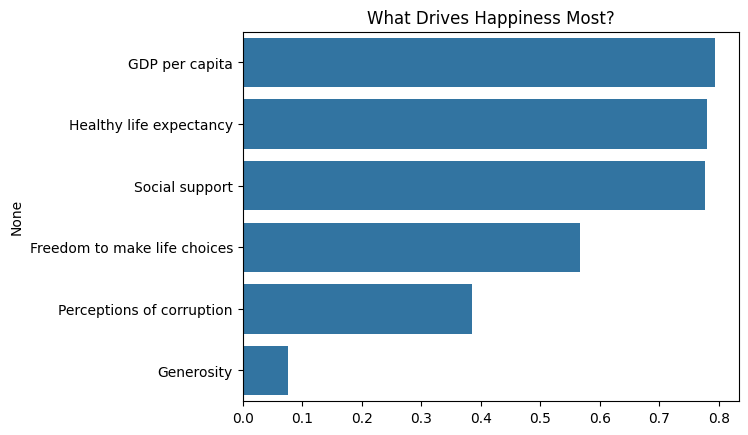

In [20]:
#barplot
sns.barplot(x="Score", y="Country or region", data=df.sort_values("Score", ascending=False).head(10))
plt.title("Top 10 Happiest Countries – 2019")
plt.show()
#histogram
sns.histplot(df['Score'], bins=20, kde=True)
plt.title("Happiness Score Distribution")
plt.show()
#scatterplot
sns.scatterplot(x="GDP per capita", y="Score", data=df)
plt.title("GDP vs Happiness Score")
plt.show()

sns.scatterplot(x="Social support", y="Score", data=df)
plt.title("Social Support vs Happiness Score")
plt.show()

factors = ['GDP per capita', 'Healthy life expectancy', 'Social support',
           'Freedom to make life choices', 'Perceptions of corruption', 'Generosity']
corr = df[factors].corrwith(df['Score']).sort_values(ascending=False)
sns.barplot(x=corr.values, y=corr.index)
plt.title("What Drives Happiness Most?")
plt.show()


Distribution Check
Mean score:      5.41
Median score:    5.38
Std. deviation:  1.11


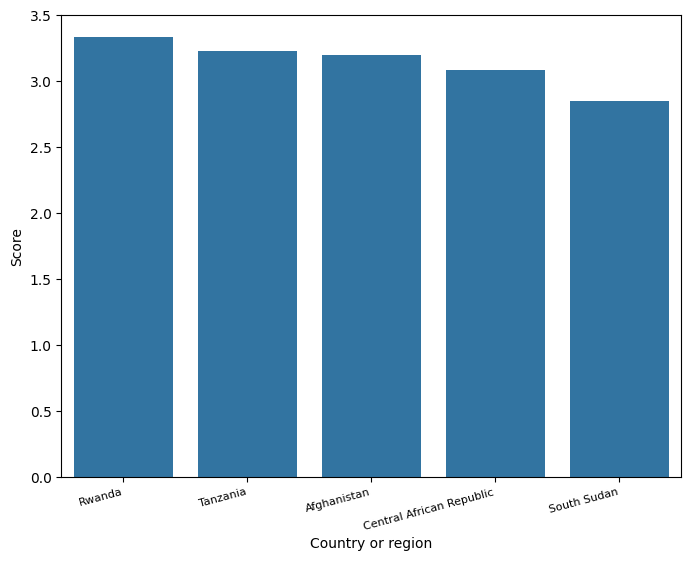

In [21]:
#bottom 5 countries
bottom5 = df.sort_values('Score', ascending=True).head(5)
plt.figure(figsize=(8, 6))
ax = sns.barplot(
    x='Country or region',
    y='Score',
    data=bottom5.sort_values('Score', ascending=False)
)
plt.xticks(fontsize=8, rotation=15, ha='right')
#distribution for the bottom 5 countries
mean_score = df['Score'].mean()
median_score = df['Score'].median()
std_score = df['Score'].std()
print("Distribution Check")
print(f"Mean score:      {mean_score:.2f}")
print(f"Median score:    {median_score:.2f}")
print(f"Std. deviation:  {std_score:.2f}")

In [22]:
print(df.sort_values(by='Score', ascending=False).head(10))

   Overall rank Country or region  Score  GDP per capita  Social support  \
0             1           Finland  7.769           1.340           1.587   
1             2           Denmark  7.600           1.383           1.573   
2             3            Norway  7.554           1.488           1.582   
3             4           Iceland  7.494           1.380           1.624   
4             5       Netherlands  7.488           1.396           1.522   
5             6       Switzerland  7.480           1.452           1.526   
6             7            Sweden  7.343           1.387           1.487   
7             8       New Zealand  7.307           1.303           1.557   
8             9            Canada  7.278           1.365           1.505   
9            10           Austria  7.246           1.376           1.475   

   Healthy life expectancy  Freedom to make life choices  Generosity  \
0                    0.986                         0.596       0.153   
1                  

In [23]:
#Exploratory checks
print(df['Country or region'].value_counts().idxmax())
print(df['Score'].max())
print(df['GDP per capita'].max())
print(df['Social support'].max())
print(df['Healthy life expectancy'].max())
print(df['Freedom to make life choices'].max())
print(df['Perceptions of corruption'].min())

Finland
7.769
1.684
1.624
1.141
0.631
0.0


In [24]:
X = df[["GDP per capita", "Social support",
        "Healthy life expectancy", "Freedom to make life choices",
        "Perceptions of corruption"]]
y = df["Score"]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25, random_state=0)

In [26]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [27]:
#Predict on our test set.
y_pred = model.predict(X_test)

In [28]:
def plot_results(x_col, y_true, y_pred=None, xlabel="", ylabel="", title=""):
    plt.scatter(x_col, y_true, color='red', label='Actual')
    if y_pred is not None:
        # sort by x for a clean line
        order = x_col.values.argsort()
        plt.plot(x_col.values[order], y_pred[order], color='blue', label='Predicted')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.show()

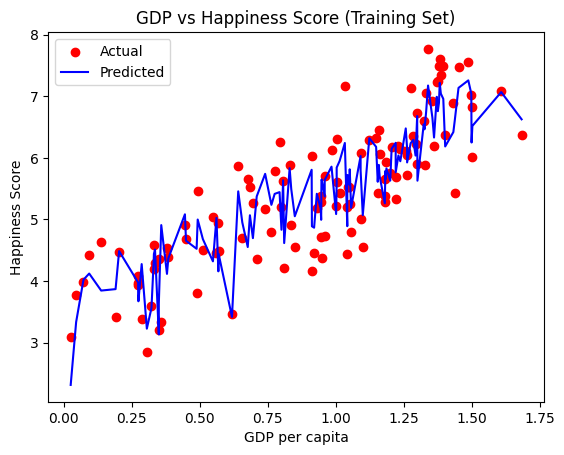

In [29]:
plot_results(X_train["GDP per capita"], y_train, model.predict(X_train),
             xlabel="GDP per capita", ylabel="Happiness Score",
             title="GDP vs Happiness Score (Training Set)")

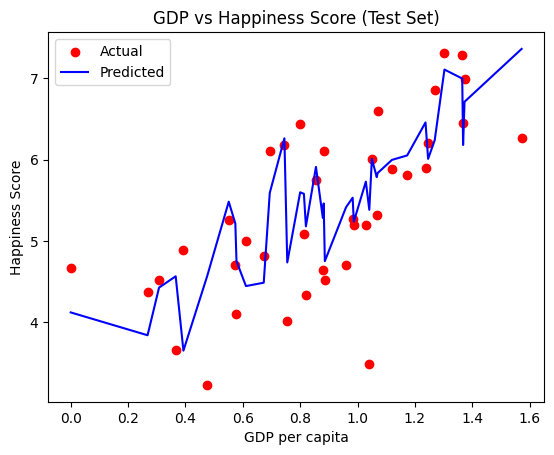

In [30]:
plot_results(X_test["GDP per capita"], y_test, y_pred,
             xlabel="GDP per capita", ylabel="Happiness Score",
             title="GDP vs Happiness Score (Test Set)")

In [31]:
score = r2_score(y_test, y_pred)
print("R² score:", "{:.0%}".format(score))

R² score: 59%
